In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import cv2
from facerecognizer import *
def take_picture_cv2(port=0, backend=cv2.CAP_DSHOW):
    cap = cv2.VideoCapture(port, backend)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open camera at port {port}")
    ok, frame_bgr = cap.read()
    cap.release()
    if not ok or frame_bgr is None:
        raise RuntimeError("Failed to capture frame")
    return frame_bgr  # BGR, shape (R, C, 3)


Boxes found: [[389.6934814453125 80.51609802246094 523.7813720703125 239.5419464111328]]
Probabilities: [0.9997174143791199]
Descriptor shape: (512,)


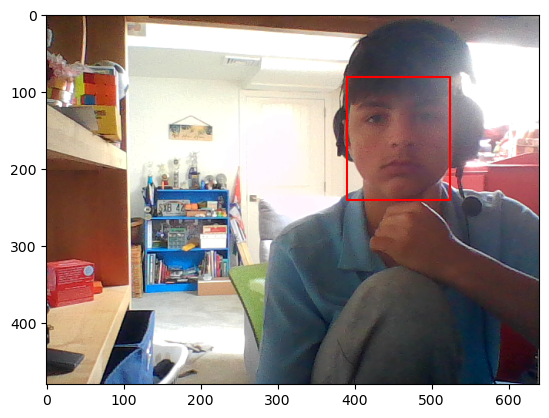

In [17]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib.pyplot as plt
from facerecognizer import jpg_to_rgb
from facenet_models import FacenetModel

model = FacenetModel()
# pick any one LFW image to test on
"""test_path = "Image_Dataset\\lfw-funneled\\lfw_funneled\\Aaron_Eckhart\\Aaron_Eckhart_0001.jpg"
img = jpg_to_rgb(image_path=test_path)"""
import matplotlib.pyplot as plt

img_bgr = take_picture_cv2()
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
boxes, probs, landmarks = model.detect(img)
print("Boxes found:", boxes)
print("Probabilities:", probs)

if boxes is not None and len(boxes) > 0:
    descriptors = model.compute_descriptors(img, boxes)
    print("Descriptor shape:", descriptors[0].shape)  # should be (512,)
else:
    print("No face detected in this image")

# visualize the detection
fig, ax = plt.subplots()
ax.imshow(img)
if boxes is not None:
    for x1, y1, x2, y2 in boxes:
        ax.plot([x1,x2,x2,x1,x1], [y1,y1,y2,y2,y1], color="red")
plt.show()

In [18]:
import os

#folder_path = "Image_Dataset\\lfw-funneled\\lfw_funneled\\Spencer_Hower"
with open('face_database.pkl', 'rb') as file:
    db = pickle.load(file)

"""add_profile(db, "Spencer")
my_photos = os.listdir(folder_path)
for photo in my_photos:
    img = jpg_to_rgb(image_path=os.path.join(folder_path, photo))
    add_images(db, "Spencer", img, model)

#print(db["Spencer"].descriptors)  # should show a list of 512-d arrays, one per photo

add_profile(db, "Aaron_Eckhart")

folder = "Image_Dataset/lfw-funneled/lfw_funneled/Aaron_Eckhart"
for file in os.listdir(folder)[:3]:  # just a few images
    path = os.path.join(folder, file)
    img = jpg_to_rgb(image_path=path)
    add_images(db, "Aaron_Eckhart", img, model)

add_profile(db, "Rudolph_Giuliani")

folder = "Image_Dataset/lfw-funneled/lfw_funneled/Rudolph_Giuliani"
for file in os.listdir(folder)[:3]:  # just a few images
    path = os.path.join(folder, file)
    img = jpg_to_rgb(image_path=path)
    add_images(db, "Rudolph_Giuliani", img, model)"""


'add_profile(db, "Spencer")\nmy_photos = os.listdir(folder_path)\nfor photo in my_photos:\n    img = jpg_to_rgb(image_path=os.path.join(folder_path, photo))\n    add_images(db, "Spencer", img, model)\n\n#print(db["Spencer"].descriptors)  # should show a list of 512-d arrays, one per photo\n\nadd_profile(db, "Aaron_Eckhart")\n\nfolder = "Image_Dataset/lfw-funneled/lfw_funneled/Aaron_Eckhart"\nfor file in os.listdir(folder)[:3]:  # just a few images\n    path = os.path.join(folder, file)\n    img = jpg_to_rgb(image_path=path)\n    add_images(db, "Aaron_Eckhart", img, model)\n\nadd_profile(db, "Rudolph_Giuliani")\n\nfolder = "Image_Dataset/lfw-funneled/lfw_funneled/Rudolph_Giuliani"\nfor file in os.listdir(folder)[:3]:  # just a few images\n    path = os.path.join(folder, file)\n    img = jpg_to_rgb(image_path=path)\n    add_images(db, "Rudolph_Giuliani", img, model)'

Identified as: Spencer_Hower, distance: 0.08678221702575684


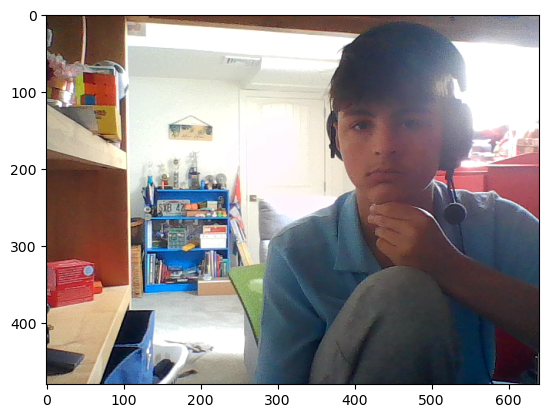

In [21]:
img_bgr = take_picture_cv2()
test_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

boxes, probs, _ = model.detect(test_img)
descriptor = model.compute_descriptors(test_img, boxes)[0]

profiles = list(db.values())
threshold = 0.4  # start loose, we'll tune this — your current placeholder is 0.01, likely too strict

name, distance = identify_face(descriptor, profiles, threshold)
print(f"Identified as: {name}, distance: {distance}")
fig, ax = plt.subplots()
ax.imshow(test_img)
plt.show()

In [22]:
for profile in profiles:
    dists = [compute_cos_dist(descriptor.reshape(1,-1), d.reshape(1,-1))[0,0] for d in profile.descriptors]
    print(profile.name, min(dists))

Aaron_Eckhart 0.94574046
Aaron_Guiel 1.2115698
Aaron_Patterson 1.077227
Aaron_Peirsol 0.784518
Aaron_Pena 0.8381478
Aaron_Sorkin 0.89219666
Aaron_Tippin 1.1070597
Abbas_Kiarostami 0.87697804
Abba_Eban 1.1264896
Abdel_Aziz_Al-Hakim 0.9295028
Abdel_Madi_Shabneh 0.99183035
Abdel_Nasser_Assidi 0.8210643
Abdoulaye_Wade 0.8179525
Abdulaziz_Kamilov 1.1263136
Abdullah 0.909071
Abdullah_Ahmad_Badawi 0.86867476
Abdullah_al-Attiyah 0.943562
Abdullah_Gul 0.9988832
Abdullah_Nasseef 0.9714567
Abdullatif_Sener 1.0092977
Abdul_Majeed_Shobokshi 1.2688389
Abdul_Rahman 1.1209452
Abel_Aguilar 0.9162153
Abel_Pacheco 0.88358057
Abid_Hamid_Mahmud_Al-Tikriti 0.94583344
Abner_Martinez 0.8137953
Abraham_Foxman 1.0146133
Aby_Har-Even 0.89519185
Adam_Ant 0.83248895
Adam_Freier 0.8887574
Adam_Herbert 1.2168193
Adam_Kennedy 1.0484713
Adam_Mair 0.77880627
Adam_Rich 0.64422363
Adam_Sandler 0.7949981
Adam_Scott 0.7286289
Adelina_Avila 0.80737543
Adel_Al-Jubeir 0.72574246
Adisai_Bodharamik 1.1838262
Adolfo_Aguilar_Zins